**Dataset Load**


In [ ]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

df = pd.read_excel("temperature_city_date_demand_1000_rows.xlsx")

print(df.head())
print(df.info())

Saving temperature_city_date_demand_1000_rows.xlsx to temperature_city_date_demand_1000_rows (6).xlsx
     DateTime       City  Temperature  Demand_MW
0  2026-01-01  Hyderabad         24.0     643.76
1  2026-01-02     Mumbai         35.3     200.17
2  2026-01-03      Delhi         31.4     403.79
3  2026-01-04  Ahmedabad         44.0     500.05
4  2026-01-05     Jaipur         22.7     568.20
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DateTime     1000 non-null   object 
 1   City         1000 non-null   object 
 2   Temperature  1000 non-null   float64
 3   Demand_MW    1000 non-null   float64
dtypes: float64(2), object(2)
memory usage: 31.4+ KB
None


**Data Cleaning**

In [ ]:
# Convert Date column
df['DateTime'] = pd.to_datetime(df['DateTime'])

# Remove duplicates
df = df.drop_duplicates()

# Check missing values
print(df.isnull().sum())

DateTime       0
City           0
Temperature    0
Demand_MW      0
dtype: int64


In [ ]:
df['Month'] = df['DateTime'].dt.month

X = df[['Temperature', 'Month']]
y = df['Demand_MW']



**EDA (Exploratory Data Analysis)**

1. Demand over time

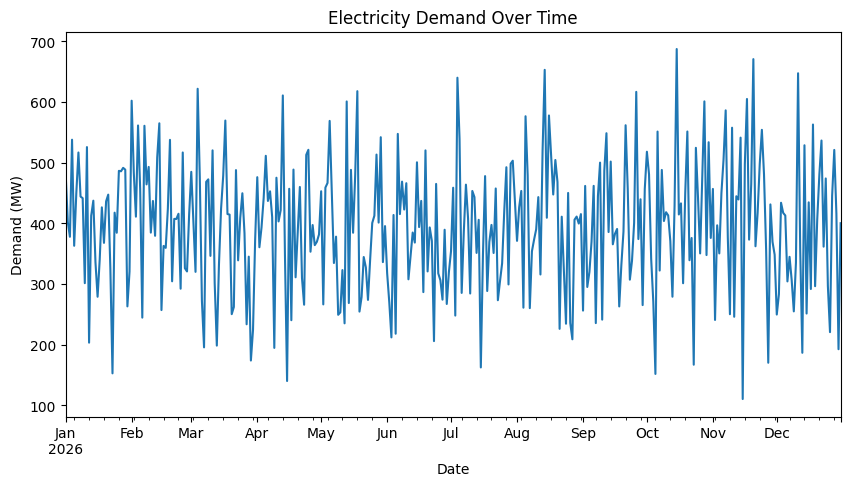

In [ ]:
import matplotlib.pyplot as plt

df.groupby('DateTime')['Demand_MW'].mean().plot(figsize=(10,5))
plt.title("Electricity Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.show()

2. City wise comparison

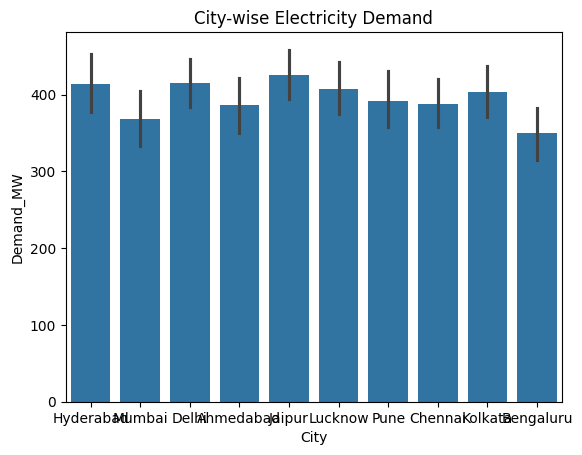

In [ ]:
import seaborn as sns

sns.barplot(x='City', y='Demand_MW', data=df)
plt.title("City-wise Electricity Demand")
plt.show()

3. Temperature vs demand


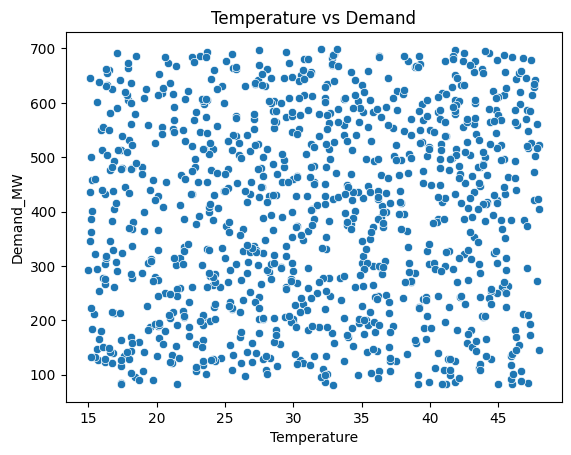

In [ ]:
sns.scatterplot(x='Temperature', y='Demand_MW', data=df)
plt.title("Temperature vs Demand")
plt.show()

**Model Building**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
predictions = model.predict(X_test)

**Model Evaluation**

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 162.48980221601752


**Visualize perdiction**

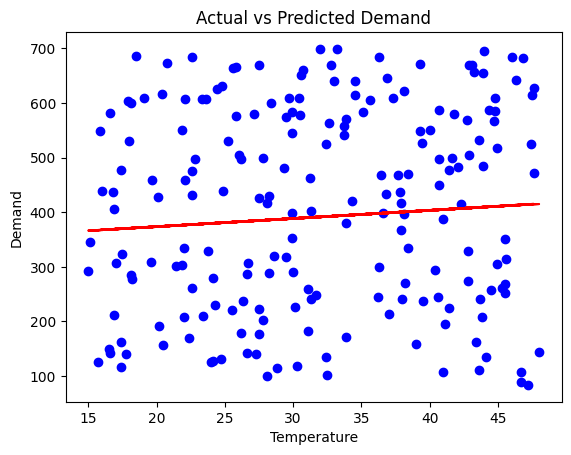

In [ ]:
plt.scatter(X_test['Temperature'], y_test, color='blue')
plt.plot(X_test['Temperature'], predictions, color='red')

plt.title("Actual vs Predicted Demand")
plt.xlabel("Temperature")
plt.ylabel("Demand")
plt.show()

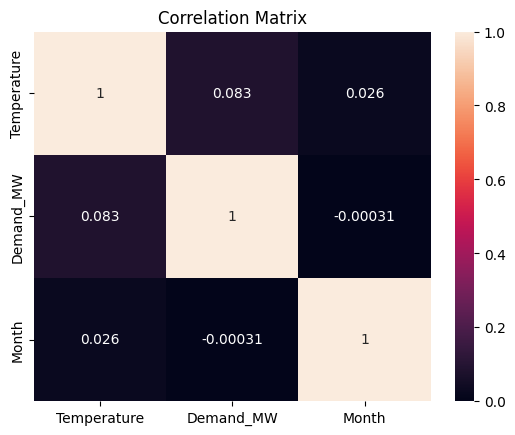

In [ ]:
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()